In [6]:
%pip uninstall -y numpy
%pip install numpy==1.23.5
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Note: you may need to restart the kernel to use updated packages.

  Using cached numpy-1.23.5-cp39-cp39-win_amd64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp39-cp39-win_amd64.whl (14.7 MB)
TensorFlow: 2.10.0
PyTorch: 2.8.0+cpu
NumPy: 1.23.5


In [7]:
# XOR input dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# XOR output
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("Input X:")
print(X)

print("\nOutput y:")
print(y)

Input X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output y:
[[0.]
 [1.]
 [1.]
 [0.]]


In [8]:
# Create Keras MLP model
keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

keras_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4)                 12        
                                                                 
 dense_1 (Dense)             (None, 1)                 5         
                                                                 
Total params: 17
Trainable params: 17
Non-trainable params: 0
_________________________________________________________________


In [9]:
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history_keras = keras_model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

print("Keras model training completed.")

Keras model training completed.


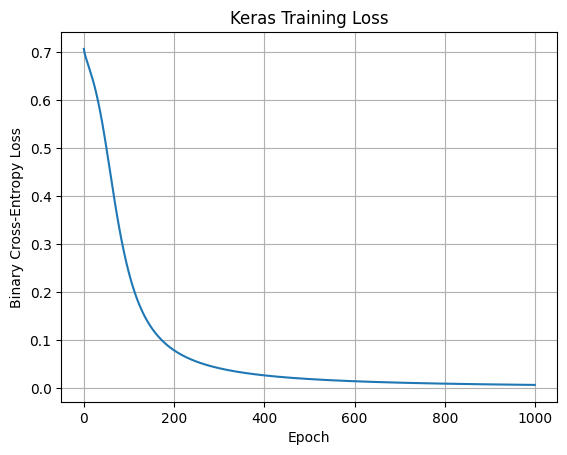

In [11]:
import matplotlib.pyplot as plt

plt.plot(history_keras.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras Training Loss")
plt.grid()
plt.show()

The Keras training loss decreases from approximately 0.71 to a value close to zero over 1000 epochs.

The steep decrease in the initial training phase indicates rapid learning, followed by a gradual reduction as the model approaches convergence. 

The smooth curve indicates stable optimization without significant oscillations. Hence, the Keras MLP successfully learns the XOR Boolean function.

In [12]:
keras_predictions = keras_model.predict(X, verbose=0)

print("Predicted probabilities:")
print(keras_predictions)

print("\nPredicted classes:")
print((keras_predictions >= 0.5).astype(int))

print("\nActual output:")
print(y.astype(int))

Predicted probabilities:
[[4.35708615e-04]
 [9.94930804e-01]
 [9.92963493e-01]
 [1.13091795e-02]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

Actual output:
[[0]
 [1]
 [1]
 [0]]


In [13]:
print("Keras XOR Results")
print("-" * 40)

for i in range(len(X)):
    probability = keras_predictions[i][0]
    predicted = int(probability >= 0.5)
    
    print(
        f"Input: {X[i].astype(int)} | "
        f"Probability: {probability:.4f} | "
        f"Predicted: {predicted} | "
        f"Actual: {int(y[i][0])}"
    )

Keras XOR Results
----------------------------------------
Input: [0 0] | Probability: 0.0004 | Predicted: 0 | Actual: 0
Input: [0 1] | Probability: 0.9949 | Predicted: 1 | Actual: 1
Input: [1 0] | Probability: 0.9930 | Predicted: 1 | Actual: 1
Input: [1 1] | Probability: 0.0113 | Predicted: 0 | Actual: 0


In [14]:
neurons_list = [2, 4, 8, 16]

for neurons in neurons_list:
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(neurons, activation="tanh"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(X, y, epochs=1000, verbose=0)

    loss, accuracy = model.evaluate(X, y, verbose=0)

    print(
        f"Hidden neurons = {neurons:2d} | "
        f"Loss = {loss:.4f} | Accuracy = {accuracy:.2f}"
    )

Hidden neurons =  2 | Loss = 0.0086 | Accuracy = 1.00
Hidden neurons =  4 | Loss = 0.0052 | Accuracy = 1.00
Hidden neurons =  8 | Loss = 0.0007 | Accuracy = 1.00
Hidden neurons = 16 | Loss = 0.0002 | Accuracy = 1.00


In [15]:
learning_rates = [0.001, 0.01, 0.05, 0.1]

for lr in learning_rates:
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation="tanh"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(X, y, epochs=1000, verbose=0)

    loss, accuracy = model.evaluate(X, y, verbose=0)

    print(
        f"Learning rate = {lr:<5} | "
        f"Loss = {loss:.4f} | Accuracy = {accuracy:.2f}"
    )

Learning rate = 0.001 | Loss = 0.2447 | Accuracy = 1.00
Learning rate = 0.01  | Loss = 0.0026 | Accuracy = 1.00
Learning rate = 0.05  | Loss = 0.0002 | Accuracy = 1.00
Learning rate = 0.1   | Loss = 0.0002 | Accuracy = 1.00


In [16]:
activations = ["relu", "tanh"]

for activation in activations:
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation=activation),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(X, y, epochs=1000, verbose=0)

    loss, accuracy = model.evaluate(X, y, verbose=0)

    print(
        f"Activation = {activation:4s} | "
        f"Loss = {loss:.4f} | Accuracy = {accuracy:.2f}"
    )

Activation = relu | Loss = 0.4779 | Accuracy = 0.75
Activation = tanh | Loss = 0.0041 | Accuracy = 1.00


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch version:", torch.__version__)

PyTorch version: 2.8.0+cpu


In [18]:
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

print(X_torch)
print(y_torch)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [19]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


torch_model = XORNet()

print(torch_model)

XORNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Tanh()
    (2): Linear(in_features=4, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


In [20]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    torch_model.parameters(),
    lr=0.01
)

In [21]:
epochs = 1000
loss_history_torch = []

for epoch in range(epochs):
    # Forward pass
    outputs = torch_model(X_torch)
    
    # Calculate loss
    loss = criterion(outputs, y_torch)
    
    # Clear old gradients
    optimizer.zero_grad()
    
    # Backpropagation
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    loss_history_torch.append(loss.item())

print("PyTorch model training completed.")

PyTorch model training completed.


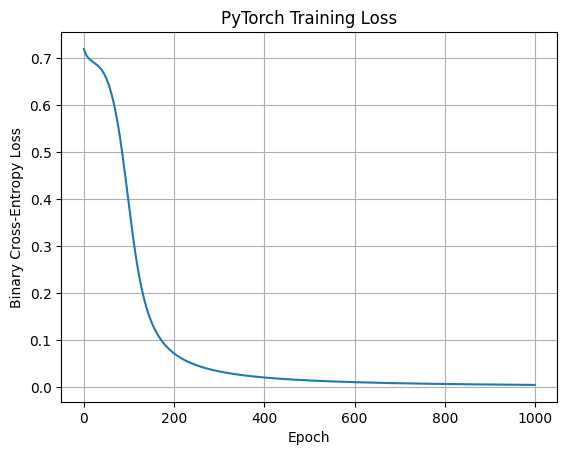

In [22]:
plt.plot(loss_history_torch)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("PyTorch Training Loss")
plt.grid()
plt.show()

The PyTorch training loss decreases from approximately 0.72 to nearly 0 as the number of epochs increases. 

The rapid decrease during the initial epochs indicates effective learning, while the gradual decrease in later epochs shows that the model is approaching convergence. 

The smooth loss curve indicates stable training. Therefore, the PyTorch MLP successfully learns the non-linear XOR function.

In [23]:
with torch.no_grad():
    torch_predictions = torch_model(X_torch)

print("Predicted probabilities:")
print(torch_predictions)

print("\nPredicted classes:")
print((torch_predictions >= 0.5).int())

print("\nActual output:")
print(y_torch.int())

Predicted probabilities:
tensor([[6.5409e-04],
        [9.9715e-01],
        [9.9234e-01],
        [6.4270e-03]])

Predicted classes:
tensor([[0],
        [1],
        [1],
        [0]], dtype=torch.int32)

Actual output:
tensor([[0],
        [1],
        [1],
        [0]], dtype=torch.int32)


In [24]:
print("PyTorch XOR Results")
print("-" * 40)

for i in range(len(X)):
    probability = torch_predictions[i].item()
    predicted = int(probability >= 0.5)
    
    print(
        f"Input: {X[i].astype(int)} | "
        f"Probability: {probability:.4f} | "
        f"Predicted: {predicted} | "
        f"Actual: {int(y[i][0])}"
    )

PyTorch XOR Results
----------------------------------------
Input: [0 0] | Probability: 0.0007 | Predicted: 0 | Actual: 0
Input: [0 1] | Probability: 0.9971 | Predicted: 1 | Actual: 1
Input: [1 0] | Probability: 0.9923 | Predicted: 1 | Actual: 1
Input: [1 1] | Probability: 0.0064 | Predicted: 0 | Actual: 0


In [25]:
for neurons in [2, 4, 8, 16]:
    model = nn.Sequential(
        nn.Linear(2, neurons),
        nn.Tanh(),
        nn.Linear(neurons, 1),
        nn.Sigmoid()
    )

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(1000):
        output = model(X_torch)
        loss = criterion(output, y_torch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        predictions = model(X_torch)
        accuracy = (
            ((predictions >= 0.5).float() == y_torch)
            .float()
            .mean()
            .item()
        )

    print(
        f"Hidden neurons = {neurons:2d} | "
        f"Accuracy = {accuracy:.2f}"
    )

Hidden neurons =  2 | Accuracy = 1.00
Hidden neurons =  4 | Accuracy = 1.00
Hidden neurons =  8 | Accuracy = 1.00
Hidden neurons = 16 | Accuracy = 1.00


In [26]:
tf.random.set_seed(42)

# Network architecture
input_size = 2
hidden_size = 4
output_size = 1

# Initialize weights and biases
W1 = tf.Variable(
    tf.random.normal([input_size, hidden_size])
)

b1 = tf.Variable(
    tf.zeros([hidden_size])
)

W2 = tf.Variable(
    tf.random.normal([hidden_size, output_size])
)

b2 = tf.Variable(
    tf.zeros([output_size])
)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 4)
b1 shape: (4,)
W2 shape: (4, 1)
b2 shape: (1,)


In [27]:
def forward_pass(X):
    # Hidden layer
    hidden = tf.matmul(X, W1) + b1
    hidden = tf.nn.tanh(hidden)
    
    # Output layer
    output = tf.matmul(hidden, W2) + b2
    output = tf.nn.sigmoid(output)
    
    return output

In [28]:
def compute_loss(y_true, y_pred):
    loss = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )
    
    return tf.reduce_mean(loss)

In [29]:
learning_rate = 0.01
epochs = 2000

loss_history_tf = []

for epoch in range(epochs):
    
    with tf.GradientTape() as tape:
        predictions = forward_pass(X)
        loss = compute_loss(y, predictions)
    
    # Calculate gradients
    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )
    
    # Update parameters
    W1.assign_sub(learning_rate * gradients[0])
    b1.assign_sub(learning_rate * gradients[1])
    W2.assign_sub(learning_rate * gradients[2])
    b2.assign_sub(learning_rate * gradients[3])
    
    loss_history_tf.append(loss.numpy())

print("TensorFlow low-level model training completed.")

TensorFlow low-level model training completed.


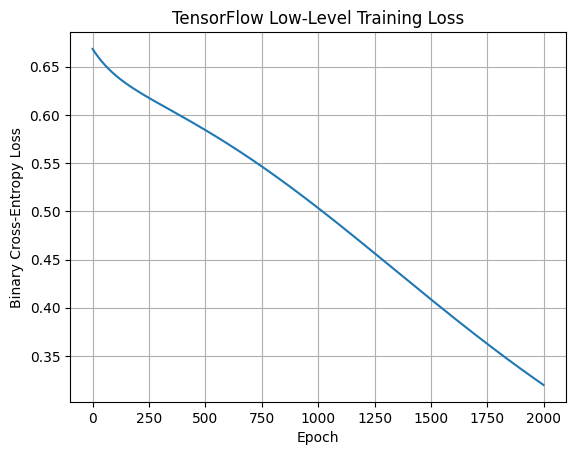

In [30]:
plt.plot(loss_history_tf)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("TensorFlow Low-Level Training Loss")
plt.grid()
plt.show()

The TensorFlow training loss decreases steadily from approximately 0.67 to 0.32 over 2000 epochs. 

The relatively faster decrease during the initial training phase indicates rapid learning, followed by a more gradual reduction as the model approaches convergence. 

The smooth and consistent curve indicates stable optimization without significant oscillations.

In [31]:
tf_predictions = forward_pass(X)

print("Predicted probabilities:")
print(tf_predictions.numpy())

print("\nPredicted classes:")
print((tf_predictions.numpy() >= 0.5).astype(int))

print("\nActual output:")
print(y.astype(int))

Predicted probabilities:
[[0.17576222]
 [0.6911488 ]
 [0.7415759 ]
 [0.3414983 ]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

Actual output:
[[0]
 [1]
 [1]
 [0]]


In [32]:
print("TensorFlow Low-Level XOR Results")
print("-" * 45)

for i in range(len(X)):
    probability = tf_predictions.numpy()[i][0]
    predicted = int(probability >= 0.5)
    
    print(
        f"Input: {X[i].astype(int)} | "
        f"Probability: {probability:.4f} | "
        f"Predicted: {predicted} | "
        f"Actual: {int(y[i][0])}"
    )

TensorFlow Low-Level XOR Results
---------------------------------------------
Input: [0 0] | Probability: 0.1758 | Predicted: 0 | Actual: 0
Input: [0 1] | Probability: 0.6911 | Predicted: 1 | Actual: 1
Input: [1 0] | Probability: 0.7416 | Predicted: 1 | Actual: 1
Input: [1 1] | Probability: 0.3415 | Predicted: 0 | Actual: 0


In [33]:
# Keras predictions
keras_classes = (keras_predictions >= 0.5).astype(int).flatten()

# PyTorch predictions
torch_classes = (
    (torch_predictions >= 0.5)
    .int()
    .numpy()
    .flatten()
)

# TensorFlow predictions
tf_classes = (
    (tf_predictions.numpy() >= 0.5)
    .astype(int)
    .flatten()
)

actual = y.astype(int).flatten()

print("XOR Prediction Comparison")
print("=" * 60)
print("Input\tActual\tKeras\tPyTorch\tTensorFlow")

for i in range(4):
    print(
        f"{X[i].astype(int)}\t"
        f"{actual[i]}\t"
        f"{keras_classes[i]}\t"
        f"{torch_classes[i]}\t"
        f"{tf_classes[i]}"
    )

XOR Prediction Comparison
Input	Actual	Keras	PyTorch	TensorFlow
[0 0]	0	0	0	0
[0 1]	1	1	1	1
[1 0]	1	1	1	1
[1 1]	0	0	0	0


In [34]:
keras_accuracy = np.mean(keras_classes == actual)
torch_accuracy = np.mean(torch_classes == actual)
tf_accuracy = np.mean(tf_classes == actual)

print("Final Accuracy")
print("-" * 30)
print(f"Keras       : {keras_accuracy * 100:.2f}%")
print(f"PyTorch     : {torch_accuracy * 100:.2f}%")
print(f"TensorFlow  : {tf_accuracy * 100:.2f}%")

Final Accuracy
------------------------------
Keras       : 100.00%
PyTorch     : 100.00%
TensorFlow  : 100.00%


All models show perfect 100% accuracy, all correct classifications

The network uses Binary Cross-Entropy loss and a suitable optimizer such as
Adam. After training, the model predicts the four XOR combinations correctly.

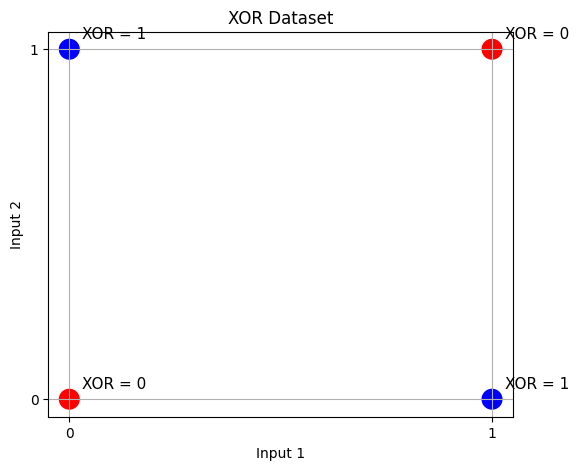

In [35]:
plt.figure(figsize=(6, 5))

colors = ["red" if value == 0 else "blue" for value in actual]

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=colors,
    s=200
)

for i in range(len(X)):
    plt.text(
        X[i, 0] + 0.03,
        X[i, 1] + 0.03,
        f"XOR = {actual[i]}",
        fontsize=11
    )

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Dataset")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid()
plt.show()

Hyperparameters

Number of neurons: Increasing the hidden neurons generally provides enough capacity to learn XOR

Learning rate: A very small learning rate can make training slow, while a very large learning rate can make training unstable.

Activation function: A non-linear activation such as Tanh or ReLU is required in the hidden layer.

Epochs: Increasing the number of epochs gives the model more opportunities to minimize the loss and learn the XOR mapping.